# 13 — PC vs PC+NC latent recentering on the LOFO folds

`08_cross_dataset_predict_new_chip.py --pc_recenter` corrects a new chip's latent
offset with **one** anchor: the positive control. The shift is

$$\Delta = \bar{z}^{\text{PC}}_{\text{ref}} - z^{\text{PC}}_{\text{own}}$$

and every test embedding is translated by it before the softmax. One anchor can only
buy a **translation**. Both controls give a second anchor, and a second anchor buys a
**scale** as well — the PC$\rightarrow$NC axis is a per-chip yardstick for how far apart
"fully amplifying" and "never amplifying" sit in latent space.

This notebook evaluates, for each of the 6 LOFO folds and 5 attn_recon variants:

| condition | latent map |
|---|---|
| `none` | $z$ (published LOFO baseline) |
| `pc` | $z + (\bar z^{PC}_{ref} - z^{PC}_{own})$ — what 08 does today |
| `nc` | $z + (\bar z^{NC}_{ref} - z^{NC}_{own})$ — NC as the sole anchor |
| `pc_nc` | $z + \tfrac12[(\bar z^{PC}_{ref}-z^{PC}_{own}) + (\bar z^{NC}_{ref}-z^{NC}_{own})]$ |
| `pc_nc_affine` | $\bar z^{mid}_{ref} + s\,(z - z^{mid}_{own})$, $s=\dfrac{\lVert\bar z^{PC}_{ref}-\bar z^{NC}_{ref}\rVert}{\lVert z^{PC}_{own}-z^{NC}_{own}\rVert}$ |

`pc_nc_affine` is a strict generalisation of `pc_nc`: setting $s=1$ recovers it exactly,
so the two differ **only** in the scalar gain, and any gap between them is attributable
to latent scale alone.

**Independence.** Nothing here is imported from or written back into the pipeline —
`04_cross_dataset_training.py`, `08_*.py` and `model_utils.py` are used read-only, via
import, and no saved model, recipe or result file is modified. The recentering maths is
re-implemented locally rather than calling 08, because 08 recomputes the reference over
*all* chips in the group; here the reference is the mean over the **5 source chips only**,
excluding the held-out one, which is the leak-safe choice for a LOFO evaluation.

**What is and isn't used from the held-out chip.** Its PC and NC well curves — a
reagent-only and a template-free well, both run on every chip by protocol and neither
carrying any target identity — plus its own PC TTP for time alignment. Its *class labels*
are used only to score the predictions.

In [1]:
import os, sys, re, time, types, importlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt

os.chdir("/vol/bitbucket/gk225/POC_DDM/gk_code/main")
sys.path.insert(0, ".")
sys.path.insert(0, "utils")
sys.path.insert(0, "utils/model_training")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import config
cdt = importlib.import_module("04_cross_dataset_training")   # read-only import
import tensorflow as tf
from model_utils import build_neighbor_curve_stack
from cross_dataset_result_io import load_partitioned
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# utils/02_outlier_detection forces the Agg backend at import time; re-assert inline
# so the figures at the bottom actually render.
%matplotlib inline

GROUP        = "final_6_new"
CURVE_TYPE   = "ori_curve_sg_p4_norm"
PC_TTP_ANCHOR = "min"
FILTER_KEY   = "noamp_remove"
TRAIN_CENTER_FRAC = 0.5
K_NEIGHBORS  = 24
BATCH        = 512

MODELS = [
    ("cnn_gru_dual_attn_recon",          "attn_recon"),
    ("cnn_gru_dual_attn_recon_dann",     "+ DANN"),
    ("cnn_gru_dual_attn_recon_supcon3",  "+ SupCon3"),
    ("cnn_gru_dual_attn_recon_mtl",      "+ MTL"),
    ("cnn_gru_dual_attn_recon_aug",      "+ temporal aug"),
]
CONDITIONS = ["none", "pc", "nc", "pc_nc", "pc_nc_affine"]

CHIPS = sorted(config.CROSS_DATASET_GROUPS[GROUP],
               key=lambda s: int(re.search(r"DDM_0(\d)", s).group(1)))
CHIP_SHORT = {n: f"chip {re.search(r'DDM_0(\d)', n).group(1)}" for n in CHIPS}
EXP_PATH = {n: Path(config.FINAL_EXP_FOLDER) / n for n in CHIPS}

OUT_DIR = (Path(config.FINAL_EXP_FOLDER) / "cross_dataset_cv" / GROUP
           / "curve_alignment_pc_ttp" / f"anchor_{PC_TTP_ANCHOR}")
PC_TTP_CACHE = Path(config.FINAL_EXP_FOLDER) / "cross_dataset_cv" / GROUP / "_cache_pc_ttp"
RESULT_CACHE = OUT_DIR / "pc_nc_recenter" / "recenter_lofo_results.joblib"
RESULT_CACHE.parent.mkdir(parents=True, exist_ok=True)

print("chips:", [CHIP_SHORT[c] for c in CHIPS])
print("out  :", OUT_DIR)
print("cache:", RESULT_CACHE)


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



chips: ['chip 1', 'chip 2', 'chip 3', 'chip 4', 'chip 5', 'chip 6']
out  : /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new/curve_alignment_pc_ttp/anchor_min
cache: /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new/curve_alignment_pc_ttp/anchor_min/pc_nc_recenter/recenter_lofo_results.joblib


## 1. Control-well curves

Positive control lives in 01's `--drop_pc` snapshot (`pc_wells`), because `--drop_pc`
lifts it out of the training pool. Negative control is still sitting in the main
`dataset` array — it is removed only later, by `LOFO_EXCLUDE_WELL_MAPPING` at combine
time — so it is read straight from `curve_for_training.joblib` and selected by the
wells whose `LABEL_MAPPINGS` entry starts with `NC`.

Both are loaded **once**, un-aligned, and re-aligned per fold: the raw curves are
fold-independent, only the alignment recipe (anchor + resampler) changes.

In [2]:
def load_raw_control(exp_path, curve_type, control):
    # PC lives in 01's --drop_pc snapshot; NC is still in the main dataset array.
    if control == "PC":
        pc = cdt.load_pc_wells_snapshot(exp_path, curve_type)
        return None if pc is None else (np.asarray(pc["curves"]), np.asarray(pc["timestamps"], float))

    data = joblib.load(os.path.join(exp_path, config.TRAINING_DATA_PATH))
    idx, _ = config.resolve_curve_dataset_idx(curve_type, list(data["dataset_name"]))
    mapping = config.LABEL_MAPPINGS[exp_path.name]
    nc_wells = [w for w, lab in mapping.items() if str(lab).startswith("NC")]
    sel = np.isin(np.asarray(data["Y_well"]), nc_wells)
    if not sel.any():
        return None
    return np.asarray(data["dataset"][idx])[sel], np.asarray(data["timestamps"], float)


t0 = time.time()
RAW_CONTROL = {}
for chip in CHIPS:
    for ctrl in ("PC", "NC"):
        RAW_CONTROL[(chip, ctrl)] = load_raw_control(EXP_PATH[chip], CURVE_TYPE, ctrl)

print(f"loaded in {time.time()-t0:.0f}s\n")
print(pd.DataFrame([
    {"chip": CHIP_SHORT[c], "PC pixels": len(RAW_CONTROL[(c,'PC')][0]),
     "NC pixels": len(RAW_CONTROL[(c,'NC')][0]),
     "NC wells": [w for w, l in config.LABEL_MAPPINGS[c].items() if str(l).startswith("NC")]}
    for c in CHIPS]).to_string(index=False))

loaded in 143s

  chip  PC pixels  NC pixels NC wells
chip 1       1828       1686      [9]
chip 2       1865       1828      [9]
chip 3       1869       1842      [9]
chip 4       1854       1774      [9]
chip 5       1896       1901      [9]
chip 6       1715       1810      [9]


## 2. Per-fold alignment and embedding helpers

`align_control` replays exactly the recipe `08_cross_dataset_predict_new_chip.py`
applies to PC in `_build_training_pc_embeddings`: shift the chip onto the group PC-TTP
anchor, truncate to the common duration, resample onto the fold's grid, and re-normalise
per curve for `*_norm` curve types.

`control_embedding` also matches 08: the control's **mean curve is tiled** into a
`(1, k+1, T)` neighbour stack, so one chip yields one anchor embedding.

In [3]:
def fold_artifacts(held_out):
    d = OUT_DIR / "model_interpretation" / f"lofo_{held_out}"
    recipe = joblib.load(d / config.CROSS_DATASET_PC_TTP_RECIPE_PATH.format(curve_type=CURVE_TYPE))
    resampler = joblib.load(d / config.CROSS_DATASET_RESAMPLER_PATH.format(curve_type=CURVE_TYPE))
    return d, recipe, resampler


def align_control(curves, timestamps, chip, recipe, resampler):
    ttp = recipe["pc_ttp_per_chip"][chip]
    ts, cu, _ = cdt.shift_to_pc_ttp_anchor(timestamps, curves, ttp, recipe["anchor"])
    ts, cu = cdt.truncate_to_common_duration(ts, cu, recipe["common_duration"])
    cu = resampler.transform(ts, cu)
    if CURVE_TYPE.endswith("_norm"):
        cu = cdt.normalize_curves_minmax(cu)
    return cu


def cls_layer(model):
    # 08's rule: the head named cls_out for DANN/SupCon/MTL, else the last layer.
    try:
        return model.get_layer("cls_out")
    except ValueError:
        return model.layers[-1]


def control_embedding(embed_model, aligned_curves):
    stack = np.tile(aligned_curves.mean(axis=0), (K_NEIGHBORS + 1, 1))[None, ...].astype(np.float32)
    return np.asarray(embed_model.predict(stack, verbose=0)[0], dtype=np.float64)

## 3. The five latent maps

Everything downstream of the encoder is a function of four anchor vectors
(`ref_pc`, `ref_nc`, `own_pc`, `own_nc`) plus the test embeddings, so all five
conditions are evaluated from a **single** encoder forward pass per (fold, model).

In [4]:
def recentered(z, cond, ref_pc, ref_nc, own_pc, own_nc):
    # Returns (mapped embeddings, scalar magnitude of the correction).
    if cond == "none":
        return z, 0.0
    if cond == "pc":
        s = ref_pc - own_pc
        return z + s, float(np.linalg.norm(s))
    if cond == "nc":
        s = ref_nc - own_nc
        return z + s, float(np.linalg.norm(s))
    if cond == "pc_nc":
        s = 0.5 * ((ref_pc - own_pc) + (ref_nc - own_nc))
        return z + s, float(np.linalg.norm(s))
    if cond == "pc_nc_affine":
        ref_mid, own_mid = 0.5 * (ref_pc + ref_nc), 0.5 * (own_pc + own_nc)
        den = float(np.linalg.norm(own_pc - own_nc))
        gain = float(np.linalg.norm(ref_pc - ref_nc)) / den if den > 0 else 1.0
        return ref_mid + gain * (z - own_mid), gain
    raise ValueError(cond)

## 4. Run the folds

For every held-out chip the pool is rebuilt with `combine_group_pc_aligned(held_out_chip=...)`,
which is what `04` itself does — the held-out chip is excluded from the *alignment statistics*
but stays in the pool, and the LOFO test set is its rows after the `noamp_remove` filter.
This reproduction was checked against the published fold accuracies (see §5).

~6 min per fold; results are cached to disk so the analysis cells below can be re-run
without recomputing.

In [5]:
FORCE_RERUN = False

def run_all_folds():
    rows, anchors = [], []
    for held in CHIPS:
        t0 = time.time()
        print(f"\n{'='*78}\n[FOLD] held out = {CHIP_SHORT[held]}  ({held})\n{'='*78}")
        fold_dir, recipe, resampler = fold_artifacts(held)

        combined = cdt.combine_group_pc_aligned(
            [EXP_PATH[c] for c in CHIPS], GROUP, curve_type=CURVE_TYPE, held_out_chip=held,
            anchor_method=PC_TTP_ANCHOR, anchor_pct=cdt.PC_TTP_ANCHOR_PCT_DEFAULT,
            pc_ttp_cache_dir=PC_TTP_CACHE)
        keep = cdt.is_amplifying_mask(combined["curves"])
        combined["features_df"][cdt.NOAMP_FILTER_NAME] = keep.astype(int)
        ns = types.SimpleNamespace(mtl=False, train_center_frac=TRAIN_CENTER_FRAC,
                                   k_neighbors=K_NEIGHBORS, batch_size=BATCH,
                                   curve_alignment="pc_ttp", pc_ttp_anchor=PC_TTP_ANCHOR)
        encoder, y_full, _, _, _, _ = cdt._derive_pool_labels(combined, ns)

        curves = combined["curves"][keep]
        coords = combined["coords"][keep]
        wells  = np.asarray(combined["well_ids"])[keep]
        ds_id  = np.asarray(combined["dataset_id"])[keep]
        y      = y_full[keep]

        te = np.where(ds_id == held)[0]
        y_te = y[te]
        X_te = build_neighbor_curve_stack(curves[te].astype(np.float32, copy=False),
                                          coords[te], wells[te], k=K_NEIGHBORS)
        del curves, coords
        print(f"  pool={len(y)}  test={len(te)}  stack={X_te.shape}")

        aligned = {(c, k): align_control(*RAW_CONTROL[(c, k)], c, recipe, resampler)
                   for c in CHIPS for k in ("PC", "NC")}
        src = [c for c in CHIPS if c != held]

        for model_key, label in MODELS:
            mp = fold_dir / f"{model_key}_{FILTER_KEY}_{CURVE_TYPE}_center{TRAIN_CENTER_FRAC:g}_model.keras"
            if not mp.exists():
                print(f"  [!] {label}: no saved model at {mp.name} -- skipped")
                continue
            tf.keras.backend.clear_session()
            model = tf.keras.models.load_model(mp, compile=False)
            head = cls_layer(model)
            embed_model = tf.keras.Model(inputs=model.input, outputs=head.input)

            e = {(c, k): control_embedding(embed_model, aligned[(c, k)])
                 for c in CHIPS for k in ("PC", "NC")}
            ref_pc = np.mean([e[(c, "PC")] for c in src], axis=0)
            ref_nc = np.mean([e[(c, "NC")] for c in src], axis=0)
            own_pc, own_nc = e[(held, "PC")], e[(held, "NC")]

            z = np.asarray(embed_model.predict(X_te, verbose=0, batch_size=BATCH), dtype=np.float64)

            anchors.append({
                "held_out": held, "model": model_key, "label": label, "dim": z.shape[1],
                "ref_pc_nc_gap": float(np.linalg.norm(ref_pc - ref_nc)),
                "own_pc_nc_gap": float(np.linalg.norm(own_pc - own_nc)),
                "shift_pc": float(np.linalg.norm(ref_pc - own_pc)),
                "shift_nc": float(np.linalg.norm(ref_nc - own_nc)),
                "cos_shift_pc_nc": float(
                    np.dot(ref_pc - own_pc, ref_nc - own_nc)
                    / (np.linalg.norm(ref_pc - own_pc) * np.linalg.norm(ref_nc - own_nc) + 1e-12)),
                "z_rms": float(np.sqrt((z ** 2).sum(axis=1).mean())),
            })

            fold_acc = {}
            for cond in CONDITIONS:
                zc, mag = recentered(z, cond, ref_pc, ref_nc, own_pc, own_nc)
                probs = head(tf.convert_to_tensor(zc, dtype=head.compute_dtype)).numpy()
                pred = probs.argmax(axis=1)
                fold_acc[cond] = accuracy_score(y_te, pred)
                rows.append({
                    "held_out": held, "chip": CHIP_SHORT[held],
                    "model": model_key, "label": label, "condition": cond,
                    "acc": fold_acc[cond],
                    "f1_macro": f1_score(y_te, pred, average="macro"),
                    "magnitude": mag, "n_test": len(y_te),
                    "classes": list(encoder.classes_),
                    "cm": confusion_matrix(y_te, pred,
                                           labels=np.arange(len(encoder.classes_))).tolist(),
                })
            print(f"  {label:16s} " + "  ".join(
                f"{c}={fold_acc[c]*100:5.2f}" for c in CONDITIONS))
            del model, embed_model, z
        del X_te
        print(f"  fold done in {time.time()-t0:.0f}s")
    return pd.DataFrame(rows), pd.DataFrame(anchors)


if RESULT_CACHE.exists() and not FORCE_RERUN:
    df, anchor_df = joblib.load(RESULT_CACHE)
    print(f"[cache] loaded {len(df)} rows from {RESULT_CACHE}")
else:
    df, anchor_df = run_all_folds()
    joblib.dump((df, anchor_df), RESULT_CACHE, compress=3)
    print(f"\n[saved] -> {RESULT_CACHE}")

[cache] loaded 150 rows from /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new/curve_alignment_pc_ttp/anchor_min/pc_nc_recenter/recenter_lofo_results.joblib


## 5. Sanity check — does `none` reproduce the published LOFO result?

If the pool rebuild, the `noamp_remove` mask or the neighbour stack differed from `04`'s,
the `none` column would not match the accuracies already in the results joblib. Small
sub-0.1 pp gaps are expected: these models were trained and scored under
`mixed_float16` + XLA, whose reduction order is not bit-reproducible.

In [6]:
published = load_partitioned(OUT_DIR, "lofo", CURVE_TYPE, train_center_frac=TRAIN_CENTER_FRAC)

chk = []
for (held, mk, label), g in df[df.condition == "none"].groupby(["held_out", "model", "label"]):
    pk = config.MODEL_KEY_MAP[mk][0]
    entry = published.get(f"lofo_{held}", {}).get(FILTER_KEY, {})
    if pk not in entry:
        continue
    pub = accuracy_score(np.asarray(entry["y_trues_"][0]), np.asarray(entry[pk][0]))
    chk.append({"chip": CHIP_SHORT[held], "model": label,
                "published %": pub * 100, "reproduced %": g.acc.iloc[0] * 100,
                "Δ pp": (g.acc.iloc[0] - pub) * 100})
chk = pd.DataFrame(chk).sort_values(["model", "chip"])
print(chk.to_string(index=False, float_format=lambda v: f"{v:6.2f}"))
print(f"\nmax |Δ| = {chk['Δ pp'].abs().max():.3f} pp over {len(chk)} (fold, model) pairs")

  chip          model  published %  reproduced %   Δ pp
chip 1         + DANN        57.68         57.66  -0.02
chip 2         + DANN        47.28         47.32   0.05
chip 3         + DANN        30.51         30.53   0.01
chip 4         + DANN        33.32         33.26  -0.05
chip 5         + DANN        43.42         43.41  -0.01
chip 6         + DANN        36.64         36.61  -0.04
chip 1          + MTL        54.04         54.05   0.01
chip 2          + MTL        59.90         59.91   0.01
chip 3          + MTL        35.19         35.19   0.00
chip 4          + MTL        33.94         33.95   0.01
chip 5          + MTL        50.83         50.83   0.00
chip 6          + MTL        21.03         21.05   0.02
chip 1      + SupCon3        59.99         60.07   0.07
chip 2      + SupCon3        53.42         53.41  -0.01
chip 3      + SupCon3        34.62         34.64   0.01
chip 4      + SupCon3        41.58         41.59   0.01
chip 5      + SupCon3        41.07         41.09

## 6. Headline table — LOFO macro accuracy by model × recentering condition

Macro over the 6 folds (unweighted mean of per-fold accuracy, matching how the LOFO
numbers are reported elsewhere), ± std across folds.

In [7]:
def macro_table(metric="acc"):
    piv = (df.groupby(["label", "condition"])[metric].agg(["mean", "std"]) * 100).reset_index()
    out = piv.pivot(index="label", columns="condition", values="mean")[CONDITIONS]
    sd  = piv.pivot(index="label", columns="condition", values="std")[CONDITIONS]
    out = out.reindex([lab for _, lab in MODELS])
    sd  = sd.reindex([lab for _, lab in MODELS])
    return out, sd

acc_t, acc_sd = macro_table("acc")
f1_t,  f1_sd  = macro_table("f1_macro")

print("LOFO macro accuracy (%), mean over 6 folds\n" + "-" * 78)
print(acc_t.round(2).to_string())
print("\nstd across folds (pp)\n" + "-" * 78)
print(acc_sd.round(2).to_string())
print("\nDelta vs. no recentering (pp)\n" + "-" * 78)
print(acc_t.sub(acc_t["none"], axis=0).round(2).to_string())
print("\n\nLOFO macro F1 (%), mean over 6 folds\n" + "-" * 78)
print(f1_t.round(2).to_string())
print("\nDelta vs. no recentering (pp)\n" + "-" * 78)
print(f1_t.sub(f1_t["none"], axis=0).round(2).to_string())

LOFO macro accuracy (%), mean over 6 folds
------------------------------------------------------------------------------
condition        none     pc     nc  pc_nc  pc_nc_affine
label                                                   
attn_recon      45.99  43.29  46.93  46.68         45.57
+ DANN          41.46  41.67  36.61  35.75         40.52
+ SupCon3       42.91  44.11  44.06  45.97         43.82
+ MTL           42.50  40.14  44.77  47.16         41.09
+ temporal aug  45.26  42.54  41.16  43.65         43.56

std across folds (pp)
------------------------------------------------------------------------------
condition        none     pc     nc  pc_nc  pc_nc_affine
label                                                   
attn_recon      10.26  13.07  15.56  12.03         11.14
+ DANN          10.11  17.94  16.80   9.53         11.60
+ SupCon3       12.17  13.37  17.64  14.17         13.56
+ MTL           14.78  17.05  21.17  17.87         18.92
+ temporal aug  11.13  14.93  18.76

## 7. Per-fold detail

A macro mean can hide a correction that rescues one bad chip while damaging four good
ones — which is the failure mode that matters for a disposable-chip deployment, where
every chip is a new fold of one.

In [8]:
for cond in CONDITIONS[1:]:
    sub = df[df.condition.isin(["none", cond])]
    piv = (sub.pivot_table(index="label", columns=["chip", "condition"], values="acc") * 100)
    delta = pd.DataFrame({
        c: piv[(c, cond)] - piv[(c, "none")] for c in sorted(df.chip.unique())
    }).reindex([lab for _, lab in MODELS])
    delta["mean"] = delta.mean(axis=1)
    delta["n improved"] = (delta[sorted(df.chip.unique())] > 0).sum(axis=1)
    print(f"\n{cond}  —  per-fold Δ accuracy vs. none (pp)\n" + "-" * 78)
    print(delta.round(2).to_string())


pc  —  per-fold Δ accuracy vs. none (pp)
------------------------------------------------------------------------------
                chip 1  chip 2  chip 3  chip 4  chip 5  chip 6  mean  n improved
label                                                                           
attn_recon      -15.22   12.07    0.54   -9.49   -1.20   -2.90 -2.70           2
+ DANN          -16.50   29.08    5.63    5.74  -11.22  -11.50  0.21           3
+ SupCon3       -13.16    9.00   11.69   -9.11   10.25   -1.52  1.19           3
+ MTL            -6.37    5.58    5.16   -9.75   -5.98   -2.77 -2.36           2
+ temporal aug  -12.65   10.73   -5.07   -8.19   -5.54    4.40 -2.72           2

nc  —  per-fold Δ accuracy vs. none (pp)
------------------------------------------------------------------------------
                chip 1  chip 2  chip 3  chip 4  chip 5  chip 6  mean  n improved
label                                                                           
attn_recon       13.20   -7.1

In [9]:
print("Per-fold accuracy (%), all conditions\n")
full = (df.pivot_table(index=["label", "condition"], columns="chip", values="acc") * 100)
full = full.reindex(pd.MultiIndex.from_product([[lab for _, lab in MODELS], CONDITIONS],
                                               names=["label", "condition"]))
full["macro"] = full.mean(axis=1)
print(full.round(2).to_string())

Per-fold accuracy (%), all conditions

chip                         chip 1  chip 2  chip 3  chip 4  chip 5  chip 6  macro
label          condition                                                          
attn_recon     none           59.08   54.53   35.17   44.14   49.29   33.73  45.99
               pc             43.87   66.60   35.72   34.64   48.08   30.83  43.29
               nc             72.29   47.38   34.24   57.49   37.69   32.48  46.93
               pc_nc          63.98   51.39   35.14   53.34   44.33   31.89  46.68
               pc_nc_affine   64.60   50.55   39.48   41.94   44.81   32.04  45.57
+ DANN         none           57.66   47.32   30.53   33.26   43.41   36.61  41.46
               pc             41.16   76.41   36.16   39.00   32.18   25.11  41.67
               nc             53.06   42.94   15.03   19.00   54.57   35.07  36.61
               pc_nc          49.03   40.94   26.03   24.73   40.89   32.85  35.75
               pc_nc_affine   56.69   40.86   33

## 8. Anchor geometry

`shift_pc` / `shift_nc` are the lengths of the two candidate translations, `cos` their
alignment. If the two controls saw the *same* chip-level drift the cosine would be near
+1 and PC alone would already capture it; a low cosine means the two anchors disagree
about the direction of the offset, which is the regime where averaging them (or fitting
a gain) can behave differently from PC alone.

`gain` is the affine scale $\lVert\bar z^{PC}_{ref}-\bar z^{NC}_{ref}\rVert / \lVert z^{PC}_{own}-z^{NC}_{own}\rVert$;
`gain` > 1 means the held-out chip's controls sit *closer together* than the source chips',
i.e. its latent space is compressed relative to training.

Norms are **not comparable across models** — plain attn_recon and the temporal-aug variant
recentre in the 64-d fused embedding, while DANN / SupCon3 / MTL recentre in their 16-d
`cls_feat` space (this is 08's `cls_out`-vs-last-layer rule). Only the ratios and the
cosine are.

In [10]:
a = anchor_df.copy()
a["chip"] = a.held_out.map(CHIP_SHORT)
a["gain"] = a.ref_pc_nc_gap / a.own_pc_nc_gap
a["shift_pc/z_rms"] = a.shift_pc / a.z_rms
a["shift_nc/z_rms"] = a.shift_nc / a.z_rms
cols = ["dim", "shift_pc", "shift_nc", "cos_shift_pc_nc", "gain", "shift_pc/z_rms", "shift_nc/z_rms"]

print("Mean over the 6 folds\n" + "-" * 78)
print(a.groupby("label")[cols].mean().reindex([lab for _, lab in MODELS]).round(3).to_string())

print("\n\nPer fold\n" + "-" * 78)
print(a.set_index(["label", "chip"])[cols]
       .reindex([lab for _, lab in MODELS], level=0).round(3).to_string())

Mean over the 6 folds
------------------------------------------------------------------------------
                 dim  shift_pc  shift_nc  cos_shift_pc_nc   gain  shift_pc/z_rms  shift_nc/z_rms
label                                                                                           
attn_recon      64.0    13.864    17.329            0.006  0.883           0.374           0.508
+ DANN          16.0    25.900    31.491            0.269  1.306           0.238           0.289
+ SupCon3       16.0     8.962     9.189           -0.024  0.941           0.293           0.314
+ MTL           16.0     8.737    16.739           -0.300  0.624           0.342           0.659
+ temporal aug  64.0     4.132    10.258           -0.086  0.877           0.360           0.955


Per fold
------------------------------------------------------------------------------
                       dim  shift_pc  shift_nc  cos_shift_pc_nc   gain  shift_pc/z_rms  shift_nc/z_rms
label          chip        

## 9. Figures

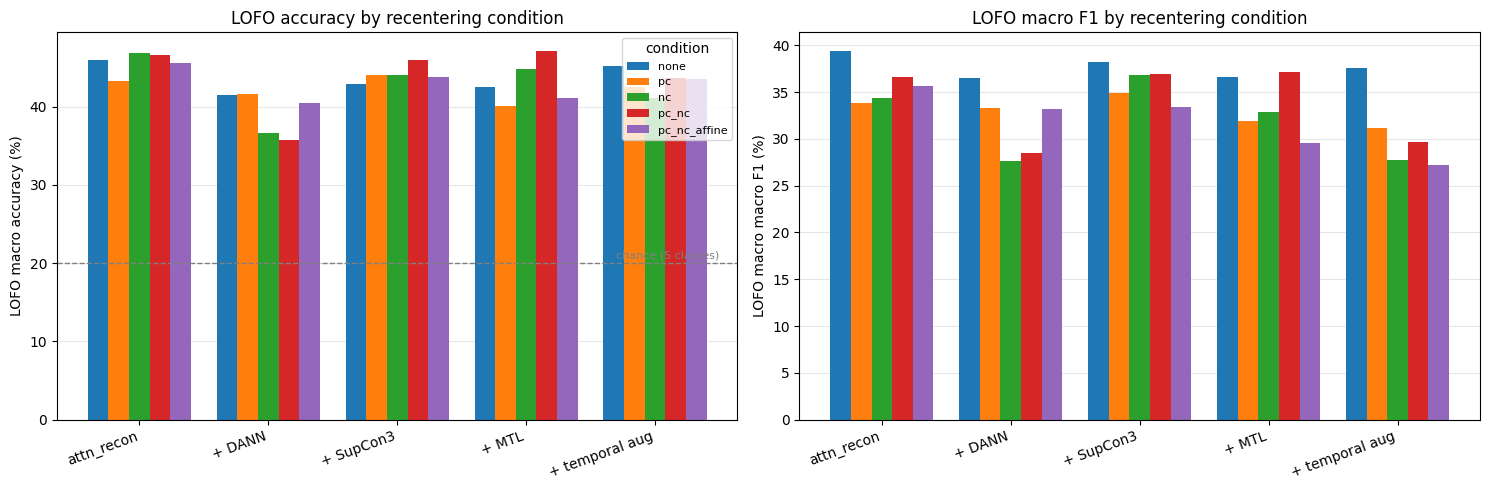

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
labels = [lab for _, lab in MODELS]
x = np.arange(len(labels)); w = 0.16
cmap = plt.get_cmap("tab10")

for ax, (tab, name) in zip(axes, [(acc_t, "accuracy"), (f1_t, "macro F1")]):
    for i, cond in enumerate(CONDITIONS):
        ax.bar(x + (i - 2) * w, tab[cond].values, w, label=cond, color=cmap(i))
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel(f"LOFO macro {name} (%)")
    ax.set_title(f"LOFO {name} by recentering condition")
    ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True)
axes[0].axhline(20, ls="--", lw=1, c="grey")
axes[0].text(len(labels) - .5, 20.6, "chance (5 classes)", ha="right", fontsize=8, color="grey")
axes[0].legend(title="condition", fontsize=8)
plt.tight_layout(); plt.show()

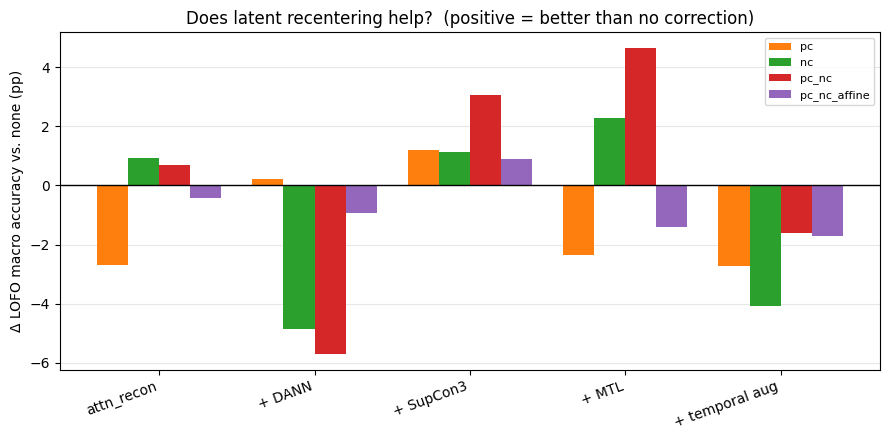

In [12]:
delta = acc_t.sub(acc_t["none"], axis=0)[CONDITIONS[1:]]
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, cond in enumerate(CONDITIONS[1:]):
    ax.bar(x + (i - 1.5) * 0.2, delta[cond].values, 0.2, label=cond, color=cmap(i + 1))
ax.axhline(0, c="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Δ LOFO macro accuracy vs. none (pp)")
ax.set_title("Does latent recentering help?  (positive = better than no correction)")
ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

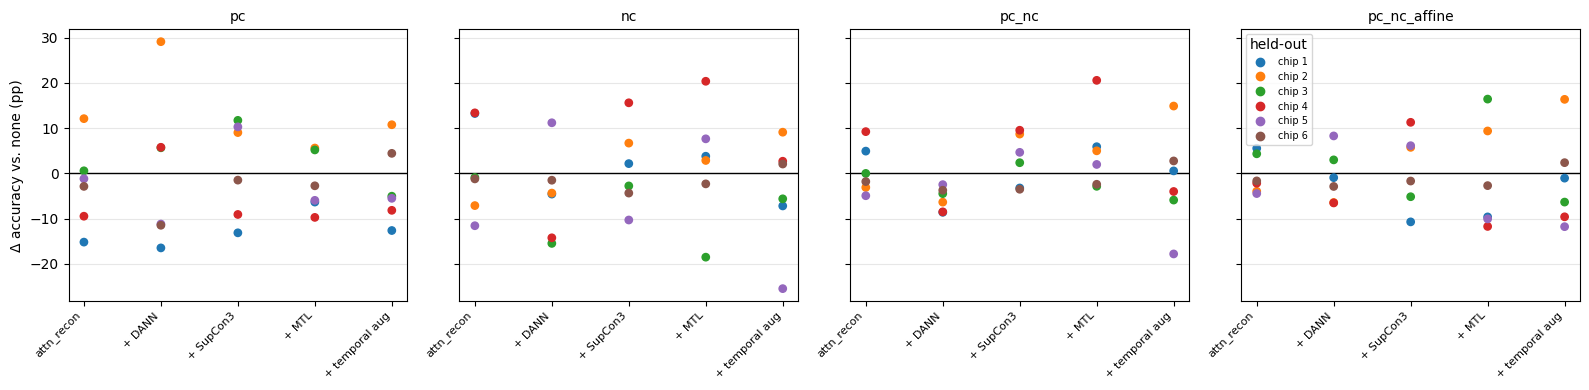

In [13]:
# Per-fold spread: one point per (model, fold), so a correction that only works on
# one chip is visible as scatter rather than being averaged away.
fig, axes = plt.subplots(1, len(CONDITIONS) - 1, figsize=(16, 4), sharey=True)
chips_sorted = sorted(df.chip.unique())
for ax, cond in zip(axes, CONDITIONS[1:]):
    base = df[df.condition == "none"].set_index(["label", "chip"]).acc
    cur  = df[df.condition == cond].set_index(["label", "chip"]).acc
    d = ((cur - base) * 100).reset_index()
    for j, lab in enumerate(labels):
        sub = d[d.label == lab]
        ax.scatter([j] * len(sub), sub.acc, s=28,
                   c=[cmap(chips_sorted.index(c)) for c in sub.chip], zorder=3)
    ax.axhline(0, c="k", lw=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(cond, fontsize=10); ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True)
axes[0].set_ylabel("Δ accuracy vs. none (pp)")
handles = [plt.Line2D([], [], marker="o", ls="", color=cmap(i), label=c)
           for i, c in enumerate(chips_sorted)]
axes[-1].legend(handles=handles, title="held-out", fontsize=7, loc="best")
plt.tight_layout(); plt.show()

## 10. Why accuracy and macro F1 disagree

Every recentering condition *loses* macro F1 while some of them gain accuracy. The
mechanism is visible in the predicted-class distribution: a translation moves the whole
test cloud in one direction, which pushes a disproportionate share of it into a single
class's decision region. When that class happens to be common on the held-out chip the
accuracy goes up; the minority classes are emptied out either way, so F1 falls.

In [14]:
def pred_stats(r):
    cm = np.array(r["cm"]); pred = cm.sum(axis=0); q = pred / pred.sum()
    return pd.Series({
        "n_pred_classes": int((pred > 0).sum()),
        "top_class_share": float(q.max()),
        "pred_entropy": float(-(q[q > 0] * np.log(q[q > 0])).sum() / np.log(len(q))),
    })

ps = df.join(df.apply(pred_stats, axis=1))
cols = ["n_pred_classes", "top_class_share", "pred_entropy"]

print("Mean over the 30 (model, fold) pairs   [entropy: 1.0 = uniform over 5 classes]\n" + "-" * 78)
print(ps.groupby("condition")[cols].mean().reindex(CONDITIONS).round(3).to_string())

print("\n\nPredicted-class entropy by model\n" + "-" * 78)
print(ps.pivot_table(index="label", columns="condition", values="pred_entropy")[CONDITIONS]
        .reindex([lab for _, lab in MODELS]).round(3).to_string())

print("\n\nLargest predicted-class share by model\n" + "-" * 78)
print(ps.pivot_table(index="label", columns="condition", values="top_class_share")[CONDITIONS]
        .reindex([lab for _, lab in MODELS]).round(3).to_string())

Mean over the 30 (model, fold) pairs   [entropy: 1.0 = uniform over 5 classes]
------------------------------------------------------------------------------
              n_pred_classes  top_class_share  pred_entropy
condition                                                  
none                   4.867            0.374         0.856
pc                     4.667            0.487         0.730
nc                     4.333            0.509         0.665
pc_nc                  4.700            0.470         0.742
pc_nc_affine           4.633            0.503         0.707


Predicted-class entropy by model
------------------------------------------------------------------------------
condition        none     pc     nc  pc_nc  pc_nc_affine
label                                                   
attn_recon      0.838  0.713  0.694  0.749         0.741
+ DANN          0.880  0.711  0.673  0.759         0.794
+ SupCon3       0.882  0.768  0.796  0.790         0.745
+ MTL           0.848  

## 11. Summary

In [15]:
best = acc_t.idxmax(axis=1)
print("Best condition per model (macro accuracy)\n" + "-" * 78)
for lab in labels:
    row = acc_t.loc[lab]
    print(f"  {lab:16s} best={best[lab]:14s} {row[best[lab]]:6.2f}%   "
          f"(none {row['none']:6.2f}%, Δ {row[best[lab]]-row['none']:+5.2f} pp)")

print("\nPooled over all 5 models\n" + "-" * 78)
pooled = df.groupby("condition").acc.mean().reindex(CONDITIONS) * 100
for c in CONDITIONS:
    print(f"  {c:14s} {pooled[c]:6.2f}%   Δ {pooled[c]-pooled['none']:+5.2f} pp")

n_pairs = df[df.condition == 'none'].shape[0]
print(f"\nWin rate over the {n_pairs} (model, fold) pairs\n" + "-" * 78)
base = df[df.condition == "none"].set_index(["label", "chip"]).acc
for c in CONDITIONS[1:]:
    cur = df[df.condition == c].set_index(["label", "chip"]).acc
    d = (cur - base) * 100
    print(f"  {c:14s} improved {int((d>0).sum()):2d}/{len(d)}   "
          f"median Δ {d.median():+5.2f} pp   worst {d.min():+6.2f} pp   best {d.max():+6.2f} pp")

Best condition per model (macro accuracy)
------------------------------------------------------------------------------
  attn_recon       best=nc              46.93%   (none  45.99%, Δ +0.94 pp)
  + DANN           best=pc              41.67%   (none  41.46%, Δ +0.21 pp)
  + SupCon3        best=pc_nc           45.97%   (none  42.91%, Δ +3.06 pp)
  + MTL            best=pc_nc           47.16%   (none  42.50%, Δ +4.67 pp)
  + temporal aug   best=none            45.26%   (none  45.26%, Δ +0.00 pp)

Pooled over all 5 models
------------------------------------------------------------------------------
  none            43.63%   Δ +0.00 pp
  pc              42.35%   Δ -1.28 pp
  nc              42.71%   Δ -0.92 pp
  pc_nc           43.84%   Δ +0.22 pp
  pc_nc_affine    42.91%   Δ -0.71 pp

Win rate over the 30 (model, fold) pairs
------------------------------------------------------------------------------
  pc             improved 12/30   median Δ -2.84 pp   worst -16.50 pp   best +29.08

### Findings

**The reproduction is exact.** `none` matches the published LOFO accuracy to within
**0.075 pp** on all 30 (fold, model) pairs, so anything below is a property of the
recentering, not of a mis-rebuilt pool.

**Adding NC does help relative to PC alone — but the whole family is a wash.**
Pooled over all 5 models: `none` 43.63%, `pc` **-1.28 pp**, `nc` **-0.92 pp**,
`pc_nc` **+0.22 pp**, `pc_nc_affine` **-0.71 pp**. `pc_nc` beats `pc` on 4 of 5 models
and is the only condition that is not net-negative, so if a control-based correction is
used at all, both controls are better than PC alone. But +0.22 pp is not a result.

**The scalar gain buys nothing.** `pc_nc_affine` is `pc_nc` plus one fitted number and
is *worse* than it on 4 of 5 models. Latent scale is not the part of the chip-to-chip
shift that matters here.

**Nothing is reliable per chip, which is the deployment-relevant unit.** Every condition
improves only 11-13 of 30 (model, fold) pairs, with a **negative median** delta in all
four cases. The spread is enormous — `pc` ranges from **-16.50 pp** (chip 1) to
**+29.08 pp** (chip 2) on DANN alone — and fold-to-fold std *rises* under recentering for
almost every model (e.g. attn_recon 10.26 -> 15.56 pp under `nc`). A correction that is a
coin flip with a +/-20 pp tail is worse than no correction on a disposable chip, where you
get one draw and cannot tell which side you landed on.

**Macro F1 falls under every single condition** (the only exception is MTL/`pc_nc`,
+0.53 pp). §10 gives the mechanism: recentering concentrates predictions — mean
predicted-class entropy drops from **0.856 to 0.665-0.742**, and the largest class's share
rises from **0.374 to 0.47-0.51**. The accuracy gains are the classifier drifting toward
whichever class is common on the held-out chip, not better discrimination.

**Chip 3 is the diagnostic case.** Its `shift_pc` is 3-5x every other chip's
(41.8 vs 2.2-12.9 for attn_recon) and its `gain` is 0.27-0.44 — its controls sit far from
the source mean *and* much further apart than the source chips'. Yet chip 3 is not
rescued by any condition. So the control offset is real and measurable, but it is not the
axis that separates the target classes.

### Reading

One anchor was never enough and two anchors do not fix it either. The premise of
control-based recentering is that the chip-to-chip difference is a rigid motion of the
whole latent cloud, which a control well can measure and undo. The `cos_shift_pc_nc`
column falsifies that premise directly: the PC and NC displacement vectors are close to
**orthogonal** (mean cosine 0.006 for attn_recon, -0.024 SupCon3, -0.300 MTL, and only
0.269 for DANN). If a single rigid shift were what separated chips, the two controls
would have measured the *same* vector. They do not, so there is no single translation for
them to agree on and averaging two disagreeing estimates cannot recover one.

This is consistent with the rest of the LOCO evidence in this project: the cross-chip gap
is not an offset sitting on top of an otherwise-shared representation, it is a change in
the representation. That is why the fixes that touch the representation itself
(augmentation, DANN, SupCon) move the needle and the post-hoc latent corrections do not.

**Practical upshot.** Do not promote `--pc_recenter` to a default, and do not extend it to
NC expecting a fix. If a control-based correction is kept for the thesis it should be
reported as `pc_nc` (the least-bad variant), with the per-fold spread shown rather than
the macro mean — the macro mean hides that it is a coin flip.